# **Airbnb's Smart Pricing Feature Model**

## Import & Load

**For Data Importing & Visualization**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**For Feature Selection**

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

**For Linear Regression**

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

**For Ridge & Lasso Regression**

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

**For Logistic Regression**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

%matplotlib inline

**Load Data**

In [7]:
import zipfile

# Programmatically extract all datasets from the uploaded zip archive
with zipfile.ZipFile('airbnb.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [8]:
# 1) Load your CSV
df_market = pd.read_csv('market_analysis.csv', sep=None, engine='python')
# 1. Define the columns you want to keep
my_cols = ['Price', 'Rent Zestimate', 'Bathrooms', 'Bedrooms','Living Area', 'City']
am_cols = ['\ufeffunified_id', 'hot_tub', 'pool']

# 2. Import the datasets using the usecols parameter
joshua_tree = pd.read_csv('sales_properties_total_zipcode_92252.csv', sep=None, engine='python', usecols=my_cols)
yucca_valley = pd.read_csv('sales_properties_total_zipcode_92284.csv', sep=None, engine='python', usecols=my_cols)
bigbear_city = pd.read_csv('sales_properties_total_zipcode_92314.csv', sep=None, engine='python', usecols=my_cols)
bigbear_lake = pd.read_csv('sales_properties_total_zipcode_92315.csv', sep=None, engine='python', usecols=my_cols)
joshuatree_pool = pd.read_csv('sales_properties_with_pool_zipcode_92252.csv', sep=None, engine='python', usecols=my_cols)
yucca_pool = pd.read_csv('sales_properties_with_pool_zipcode_92284.csv', sep=None, engine='python', usecols=my_cols)
df_amenities = pd.read_csv('amenities.csv', sep=None, engine='python', usecols=am_cols)


**Dataframe Copies**

In [9]:
# Create working copies so the original imports remain untouched
market = df_market.copy()
amenities = df_amenities.copy()

# Create one master sales dataframe
sales_raw = pd.concat([joshua_tree, yucca_valley, bigbear_city, bigbear_lake, joshuatree_pool, yucca_pool], ignore_index=True)

# Create the working copy for cleaning
sales_clean = sales_raw.copy()

## Data Wrangling

**Data Cleaning**

In [10]:
# 1.----- Renames Unified_ID (Removes hidden characters)...
for df in [market, amenities]:
    cols = df.columns.tolist()
    cols[0] = 'unified_id'  # Force the first column to be named exactly 'unified_id'
    df.columns = cols
    
# 2.----- Convert market_data columns below from "," to "."...
cols_to_fix = ['revenue', 'occupancy', 'nightly rate', 'lead time', 'length stay']
for col in cols_to_fix:
    market[col] = market[col].astype(str).str.replace(',', '.').astype(float)

# 3.----- Remove'AIR' from amenities_data unified_id numbers...
amenities['unified_id'] = amenities['unified_id'].astype(str).str.replace('AIR', '').astype(int)

#----- 4. Convert 'month' to datetime in all sets for a clean merge key
for df in [market]:
    df['month'] = pd.to_datetime(df['month'])

#----- 5. Create the new columns using .loc[all_rows, new_column_name]
# This explicitly tells Pandas to write to the 'market' dataframe
market.loc[:, 'year'] = market['month'].dt.year
market.loc[:, 'month_num'] = market['month'].dt.month

# Now it is safe to drop the original column
market = market.drop(columns=['month'])

**Fixing NaN Values**

In [11]:
# ----- Nightly Rate -----
# 1. Calculate the actual number of days booked
# We use max(1) to avoid dividing by zero if a place had 0 bookings
days_booked = (market['openness'] * market['occupancy']).clip(lower=1)

# 2. Calculate the nightly rate 
calculated_rate = market['revenue'] / days_booked

# 3. Only fill the NaNs in the 'nightly rate' column with our calculation
market['nightly rate'] = market['nightly rate'].fillna(calculated_rate)

# 4. Check how many NaNs are left
print(f"Remaining Nightly Rate NaNs: {market['nightly rate'].isnull().sum()}")

Remaining Nightly Rate NaNs: 6


In [12]:
# ----- Revenue / Nightly Rate NaNs Dropped -----
# Drop the 6 rows where revenue is missing
market = market.dropna(subset=['revenue'])

# 4. Check how many NaNs are left
print(f"Remaining Nightly Rate NaNs: {market['nightly rate'].isnull().sum()}")

Remaining Nightly Rate NaNs: 0


In [13]:
# ----- Lead Time & Length Stay -----
# 1. Now calculate the medians
lead_median = market['lead time'].median()
stay_median = market['length stay'].median()

# 2. Fill the NaNs using .loc[row_indexer, col_indexer]
# The colon : means "all rows"
market.loc[:, 'lead time'] = market['lead time'].fillna(lead_median)
market.loc[:, 'length stay'] = market['length stay'].fillna(stay_median)

# 3. Verify the fix
print(f"Lead Time NaNs: {market['lead time'].isnull().sum()}")
print(f"Length Stay NaNs: {market['length stay'].isnull().sum()}")

Lead Time NaNs: 0
Length Stay NaNs: 0


**Convert Dtypes**

In [14]:
# 1. Convert Zipcodes to Strings
market['zipcode'] = market['zipcode'].astype(str)

# 2. Convert Guests to Integer
# 'coerce' turns any non-numbers into NaN so the code doesn't crash
market['guests'] = pd.to_numeric(market['guests'], errors='coerce').fillna(0).astype(int)

# 3. Convert Length Stay to Integer
market['length stay'] = market['length stay'].astype(int)

# 4. Verify the changes
print(market[['zipcode', 'guests', 'length stay']].dtypes)

zipcode        object
guests          int64
length stay     int64
dtype: object


**Data Integration**

In [15]:
# 1. Clean the AMENITIES dataframe so each house is only listed ONCE.
# We sort to make sure if a '1' (Yes) exists for a pool/tub, we keep it.
amenities_clean = amenities.sort_values(['unified_id', 'hot_tub', 'pool'], ascending=[True, False, False])
amenities_clean = amenities_clean.drop_duplicates(subset='unified_id')

# 2. Now merge your full MARKET data (116k rows) with the cleaned AMENITIES (one row per house)
# This will keep your row count at exactly 116,613.
airbnb = market.merge(amenities_clean, on='unified_id', how='left')

# 3. Fill any houses not found in the amenities list with 0 (assuming no pool/tub)
airbnb.loc[:, ['hot_tub', 'pool']] = airbnb[['hot_tub', 'pool']].fillna(0)

# 4. Final verification
print(f"Original Market Rows: {market.shape[0]}")
print(f"New Airbnb Rows: {airbnb.shape[0]}")
print("\nCheck if Pool/Hot Tub are attached to the monthly data:")
print(airbnb[['unified_id', 'year', 'month_num', 'hot_tub', 'pool']].head(10))

Original Market Rows: 116613
New Airbnb Rows: 116613

Check if Pool/Hot Tub are attached to the monthly data:
   unified_id  year  month_num  hot_tub  pool
0    10000347  2020          1      0.0   0.0
1    10000347  2020         10      0.0   0.0
2    10000347  2020         11      0.0   0.0
3    10000347  2020         12      0.0   0.0
4    10000347  2020          2      0.0   0.0
5    10000347  2020          3      0.0   0.0
6    10000347  2020          4      0.0   0.0
7    10000347  2020          7      0.0   0.0
8    10000347  2020          8      0.0   0.0
9    10000347  2020          9      0.0   0.0


In [16]:
# Exporting the cleaned dataset for Tableau
airbnb.to_csv('cleaned_airbnb_data2.csv', index=False)

## Feature Engineering

**Categorical Columns**

In [17]:
# 1. Create a list of the categorical columns you want to transform
categorical_cols = ['city', 'host_type']

# 2. Use get_dummies to create the new columns
# drop_first=True is a "pro" move for regression to avoid the 'Dummy Variable Trap'
dummies = pd.get_dummies(airbnb[categorical_cols], drop_first=True)

# 3. Join the dummies back to the airbnb dataframe and drop the original text columns
airbnb = pd.concat([airbnb, dummies], axis=1).drop(columns=categorical_cols)

# 4. Verify the new columns exist (you'll see columns like city_Joshua Tree, host_type_Superhost)
print(airbnb.columns[-10:])

Index(['length stay', 'year', 'month_num', 'hot_tub', 'pool',
       'city_Big Bear Lake', 'city_Joshua Tree', 'city_Yucca Valley',
       'host_type_Professionals', 'host_type_Single Owners'],
      dtype='object')


**Season Mapping**

In [18]:
# 1. Define the mapping dictionary
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}

# 2. Create the 'season' column in your airbnb dataframe
airbnb['season'] = airbnb['month_num'].map(season_map)

# 1. Create the dummy columns
season_dummies = pd.get_dummies(airbnb['season'], prefix='season', drop_first=True)

# 2. Add them to your main dataframe and remove the original text column
airbnb = pd.concat([airbnb, season_dummies], axis=1).drop(columns=['season'])

# 3. Check your new columns
print(airbnb.columns[-5:])

Index(['host_type_Professionals', 'host_type_Single Owners', 'season_Spring',
       'season_Summer', 'season_Winter'],
      dtype='object')


**Adding a Successful Nightly Rate Column**

In [19]:
# 1. Create a binary target: 1 if price is above median, 0 if below
median_price = airbnb['nightly rate'].median()
airbnb['is_high_price'] = (airbnb['nightly rate'] > median_price).astype(int)

**Amenities Column Fix**

In [20]:
# 1. Use DOUBLE brackets [[ ]] to select multiple columns
# Also, .mean() needs to be calculated for the specific columns
cols_to_fix = ['pool', 'hot_tub']
airbnb[cols_to_fix] = airbnb[cols_to_fix].fillna(airbnb[cols_to_fix].mean())

# 2. Update your Feature matrix (X) to include these new columns
y = airbnb['is_high_price']
X = airbnb[['bedrooms', 'bathrooms', 'pool', 'hot_tub']]

**Convert ID to String after Merge**

In [21]:
airbnb['unified_id'] = airbnb['unified_id'].astype(str)

In [22]:
airbnb.dtypes

unified_id                  object
zipcode                     object
bedrooms                     int64
bathrooms                  float64
guests                       int64
revenue                    float64
openness                     int64
occupancy                  float64
nightly rate               float64
lead time                  float64
length stay                  int64
year                         int32
month_num                    int32
hot_tub                    float64
pool                       float64
city_Big Bear Lake            bool
city_Joshua Tree              bool
city_Yucca Valley             bool
host_type_Professionals       bool
host_type_Single Owners       bool
season_Spring                 bool
season_Summer                 bool
season_Winter                 bool
is_high_price                int64
dtype: object

In [23]:
airbnb.describe()

,bedrooms,bathrooms,guests,revenue,openness,occupancy,nightly rate,lead time,length stay,year,month_num,hot_tub,pool,is_high_price
count,116613.000000,116613.000000,116613.000000,116613.000000,116613.000000,116613.000000,116613.000000,116613.000000,116613.000000,116613.000000,116613.000000,116613.000000,116613.000000,116613.000000
mean,3.401533,2.402579,7.995301,5745.195040,28.335434,0.438276,360.735004,31.286338,4.148808,2021.143706,6.714509,0.266077,0.042474,0.499816
std,0.633795,0.793941,2.839341,7264.663998,6.161817,0.345914,355.250535,34.349558,14.836302,0.805353,3.479176,0.441907,0.201668,0.500002
min,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,2020.000000,1.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,6.000000,796.000000,30.000000,0.100000,156.800000,14.833333,2.000000,2020.000000,4.000000,0.000000,0.000000,0.000000
50%,3.000000,2.000000,8.000000,3811.000000,30.000000,0.419355,295.000000,22.916667,2.000000,2021.000000,7.000000,0.000000,0.000000,0.000000
75%,4.000000,3.000000,10.000000,8000.000000,31.000000,0.741935,490.842105,33.875000,3.000000,2022.000000,10.000000,1.000000,0.000000,1.000000
max,5.000000,7.000000,14.000000,151900.000000,31.000000,1.000000,10000.000000,364.000000,365.000000,2022.000000,12.000000,1.000000,1.000000,1.000000


## Feature Selection

In [24]:
# Target Variable
y = airbnb['nightly rate']

In [25]:
airbnb.corr()['nightly rate'].sort_values()

season_Summer             -0.098338
season_Spring             -0.097398
unified_id                -0.040961
host_type_Single Owners   -0.036940
city_Joshua Tree          -0.002613
city_Yucca Valley          0.001282
zipcode                    0.003604
host_type_Professionals    0.018236
month_num                  0.020762
length stay                0.026512
year                       0.032186
guests                     0.033380
city_Big Bear Lake         0.069840
pool                       0.071982
hot_tub                    0.123260
lead time                  0.132676
openness                   0.134428
season_Winter              0.237885
occupancy                  0.324843
bedrooms                   0.326397
bathrooms                  0.355155
is_high_price              0.659134
revenue                    0.776864
nightly rate               1.000000
Name: nightly rate, dtype: float64

In [26]:
# Show only the correlation with Nightly Rate
price_corr = airbnb.corr(numeric_only=True)[['nightly rate']].sort_values(by='nightly rate', ascending=False)

plt.figure(figsize=(4, 8))
sns.heatmap(price_corr, annot=True, cmap='coolwarm', center=0)


<Axes: >

In [27]:
selected_features = ['bedrooms', 'bathrooms']
X = airbnb[selected_features]

In [28]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [29]:
# Create a model for Linear Regression
model = LinearRegression()

# Fit the model with the Training data
model.fit(X_train, y_train)

# Calculate the score (R^2 for Regression) for Training Data
model.score(X_train, y_train)

# Calculate the score (R^2 for Regression) for Testing Data
model.score(X_test, y_test)

0.1377459166390509

In [30]:
# Set up 5-fold cross validation
k_fold = KFold(5, shuffle=True)
train_scores = []
train_rmse = []
test_scores = []
test_rmse = []

for k, (train, test) in enumerate(k_fold.split(X)):

    # Get training and test sets for X and y
    X_train = X.iloc[train, ]
    y_train = y.iloc[train, ]
    X_test = X.iloc[test, ]
    y_test = y.iloc[test, ]

    # Fit model with training set
    model.fit(X_train, y_train)

    # Make predictions with training and test set
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    # Score R2 and RMSE on training and test sets and store in list
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

    # Change these lines inside your loop:
    train_rmse.append(mean_squared_error(y_train, train_preds))
    test_rmse.append(mean_squared_error(y_test, test_preds))
# Create a metrics_df dataframe to display r2 and rmse scores
metrics_df = pd.DataFrame({'Training R2': train_scores,
                           'Test R2': test_scores,
                           'Training RMSE': train_rmse,
                           'Test RMSE': test_rmse},
                          index=[i+1 for i in range(5)])

metrics_df

,Training R2,Test R2,Training RMSE,Test RMSE
1,0.145596,0.152314,106548.531014,112046.713890
2,0.146552,0.149006,108765.563338,103169.346698
3,0.148226,0.141590,109010.941079,102202.567944
4,0.145633,0.152643,108001.533690,106227.333073
5,0.149213,0.138820,105894.790684,114651.602188


## 1.Linear Regression Model

In [31]:
model = LinearRegression()

In [32]:
X = airbnb[['bedrooms', 'bathrooms']]
y = airbnb[['nightly rate']]

In [33]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
print("Coefficient (Slope):", model.coef_)
print("Intercept:", model.intercept_)

Coefficient (Slope): [[100.40959819 111.58067256]]
Intercept: [-248.89301935]


In [35]:
r2=model.score(X, y)

print(f"R^2 is {r2}.")

R^2 is 0.1470348550324302.


In [36]:
## Create training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [37]:
## Check training/test data
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (78130, 2)
Testing set shape: (38483, 2)


In [38]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
print("Test R2 Score:", model.score(X_test, y_test))

Test R2 Score: 0.13907051644688384


In [40]:
predicted_price = model.predict([[4,3]])

print(predicted_price)

[[488.23895739]]


C:\Users\mia62\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [41]:
# Predict prices from X_test
y_preds = model.predict(X_test)

# Compare with actual y_test
mse = mean_squared_error(y_test, y_preds)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error (Average $ error):", np.sqrt(mse))

Mean Squared Error: 113011.99704324285
Root Mean Squared Error (Average $ error): 336.17257033143386


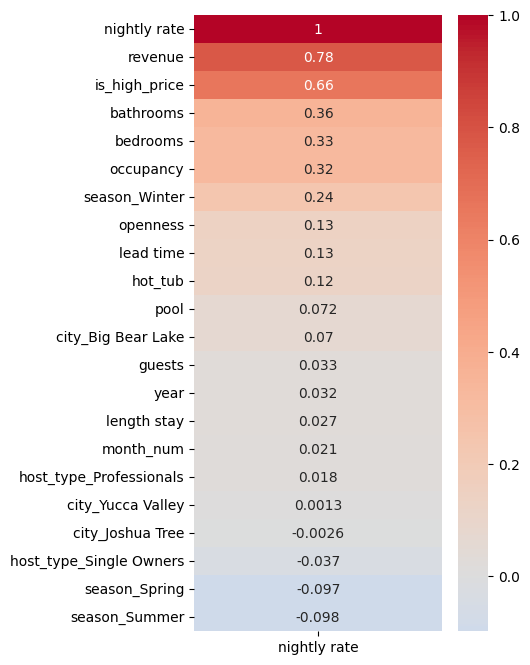

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


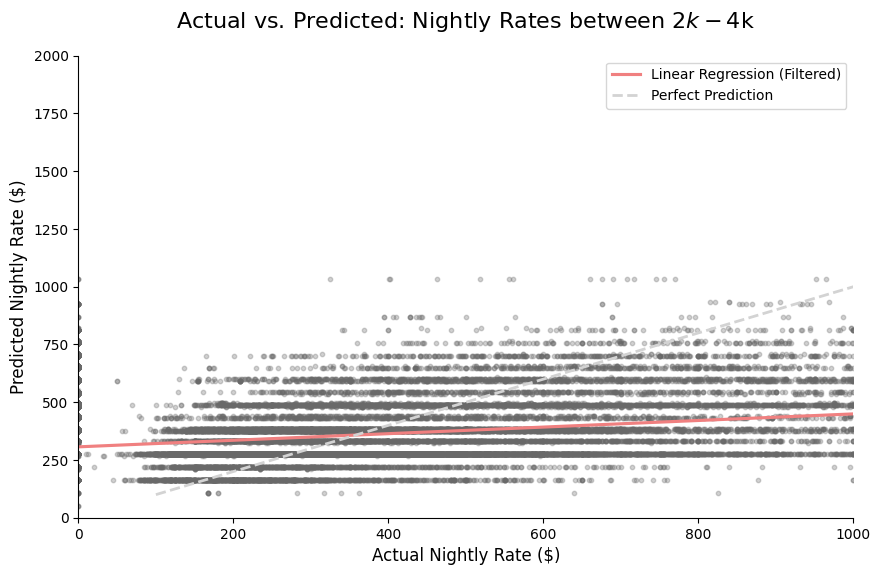

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Filter your TEST set to only show the range from Cell [151]
# We use the index of y_test to make sure we're looking at the right rows
plot_mask = (y_test['nightly rate'] <= 1000)
y_test_filtered = y_test[plot_mask]
y_preds_filtered = y_preds[plot_mask]

# 2. Plotting the filtered data
plt.figure(figsize=(10, 6))

sns.regplot(
    x=y_test_filtered['nightly rate'], 
    y=y_preds_filtered.flatten(), # use .flatten() if y_preds is 2D
    scatter_kws={'alpha': 0.3, 'color': 'dimgrey', 's': 10}, 
    line_kws={'color': 'lightcoral', 'label': 'Linear Regression (Filtered)'}
)

# 3. Dynamic Axis Limits based on your filter
plt.xlim(0, 1000)
plt.ylim(0, 2000) # Adjusted because your model tends to under-predict high values

# 4. Perfect Prediction Line for this specific zoom
plt.plot([100, 1000], [100, 1000], color='lightgrey', lw=2, linestyle='--', label='Perfect Prediction')

# Formatting
plt.title('Actual vs. Predicted: Nightly Rates between $2k - $4k', fontsize=16, pad=20)
plt.xlabel('Actual Nightly Rate ($)', fontsize=12)
plt.ylabel('Predicted Nightly Rate ($)', fontsize=12)
plt.legend()
sns.despine()

plt.show()

C:\Users\mia62\AppData\Local\Temp\ipykernel_14920\1753522391.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  val_max = max(float(y_test.max()), float(y_preds.max()))
C:\Users\mia62\AppData\Local\Temp\ipykernel_14920\1753522391.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  val_min = min(float(y_test.min()), float(y_preds.min()))


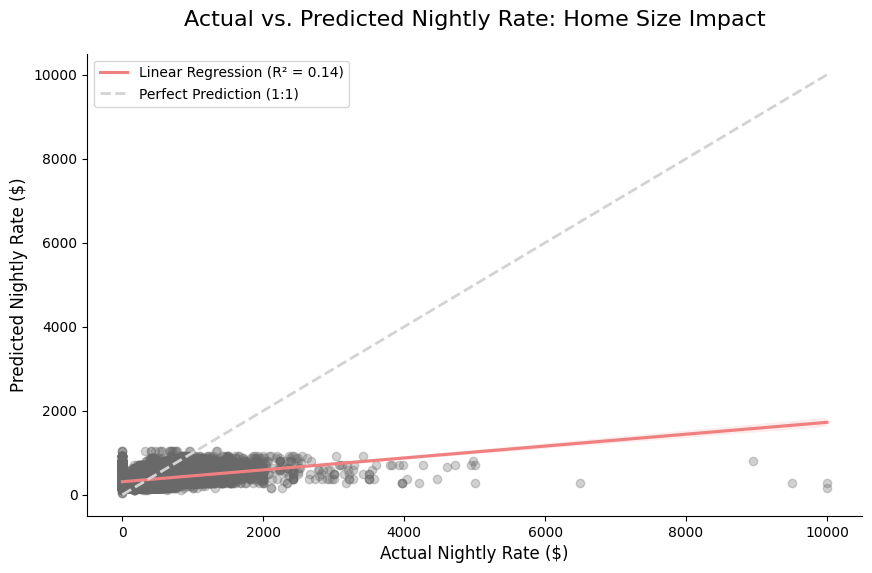

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use the predictions from your model in cell [115]
# Note: Changing 'predictions' to 'y_preds' to match your previous cell
plt.figure(figsize=(10, 6))

# 1. Plot the points (Actual vs Predicted) and the best-fit line
sns.regplot(x=y_test, y=y_preds, 
            scatter_kws={'alpha': 0.3, 'color': 'dimgrey'}, 
            line_kws={'color': 'lightcoral', 'label': f'Linear Regression (R² = {model.score(X_test, y_test):.2f})'})

# 2. Perfect Prediction line for comparison (Ideal 1:1)
# We convert to float to ensure max() receives simple numbers
val_max = max(float(y_test.max()), float(y_preds.max()))
val_min = min(float(y_test.min()), float(y_preds.min()))

plt.plot([val_min, val_max], [val_min, val_max], 
         color='lightgrey', lw=2, linestyle='--', 
         label='Perfect Prediction (1:1)')
# Formatting
plt.title('Actual vs. Predicted Nightly Rate: Home Size Impact', fontsize=16, pad=20)
plt.xlabel('Actual Nightly Rate ($)', fontsize=12)
plt.ylabel('Predicted Nightly Rate ($)', fontsize=12)
plt.legend()
sns.despine()

# Save for your presentation
plt.savefig('regression_homesize.png', transparent=True, dpi=300)
plt.show()

## 2.Lasso/Ridge Regularization Models

### **Ridge**

In [44]:
# Target
y = market['nightly rate']

In [45]:
# Create Model
model = LinearRegression()

In [46]:
# 2. Define the target name
target_name = 'nightly rate'

# 3. Create X and y from the SAME source (airbnb)
# This ensures they have the same number of rows (samples)
X = airbnb.select_dtypes(include=[np.number]).drop(columns=[target_name, 'unified_id'], errors='ignore')
y = airbnb[target_name]

# 4. Final safety check: remove any remaining NaNs across both simultaneously
common_data = pd.concat([X, y], axis=1).dropna()
X = common_data.drop(columns=[target_name])
y = common_data[target_name]

# 5. Now fit your model
model.fit(X, y)
print("Model fitted successfully!")

Model fitted successfully!


In [47]:
# Score
model.score(X,y)

0.7365344377398568

In [48]:
# Check Coeffieicent
model.coef_

array([ 2.87103501e+01,  2.00673184e+01, -4.61596969e+00,  3.43231717e-02,
       -1.53686737e+00, -2.00811489e+02,  8.70896420e-02, -3.09809706e-01,
        1.12565703e+01,  1.15022109e+00, -4.52292852e+00,  1.89547677e+01,
        2.42574771e+02])

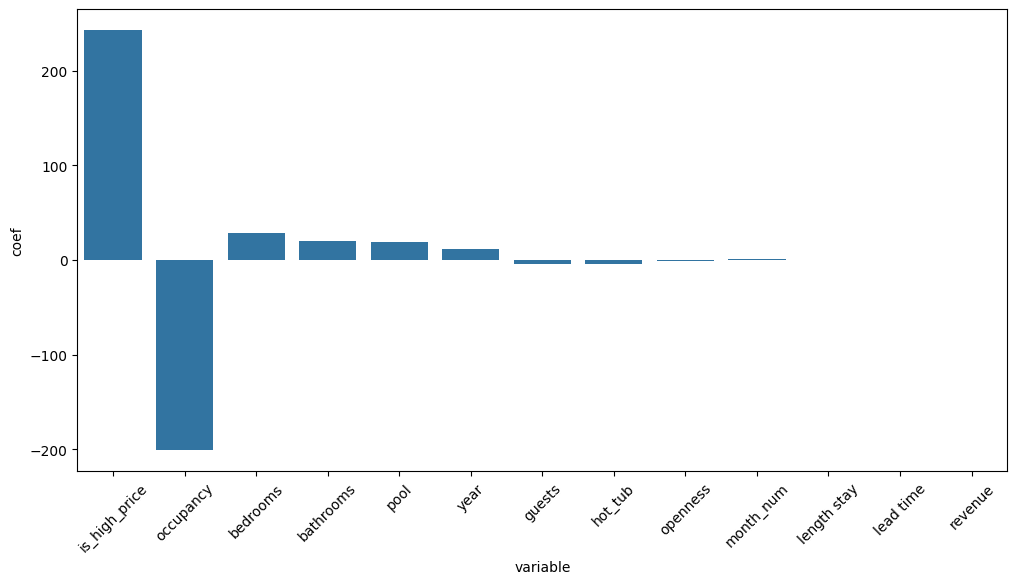

In [49]:
def view_coeff(X, model):
    # 1. Create the dataframe (Inside the function)
    model_coefs = pd.DataFrame({
        'variable': X.columns,
        'coef': model.coef_,
        'abs_coef': np.abs(model.coef_)
    })
    model_coefs.sort_values('abs_coef', inplace=True, ascending=False)
    
    # 2. Set the figure size (Inside the function)
    plt.figure(figsize=(12, 6))
    
    # 3. Create the plot (Now it can see model_coefs!)
    sns.barplot(x="variable", y="coef", data=model_coefs)
    
    # 4. Cleanup labels
    plt.xticks(rotation=45)
    plt.show()

# --- NOW CALL THE FUNCTION ---
view_coeff(X, model)

In [50]:
## Calculate Ridge Regression model

# create a model object to hold the modelling parameters
ridgemodel = Ridge()

# keep track of the intermediate results for coefficients and errors
coefs = []
errors = []

# create a range of alphas to calculate
ridge_alphas = np.logspace(-6, 6, 200) #lambda in the slides

# Train the model with different regularization strengths
for a in ridge_alphas:
    ridgemodel.set_params(alpha = a)
    ridgemodel.fit(X, y)
    coefs.append(ridgemodel.coef_)
    errors.append(mean_squared_error(ridgemodel.coef_, model.coef_))

In [51]:
len(coefs)

200

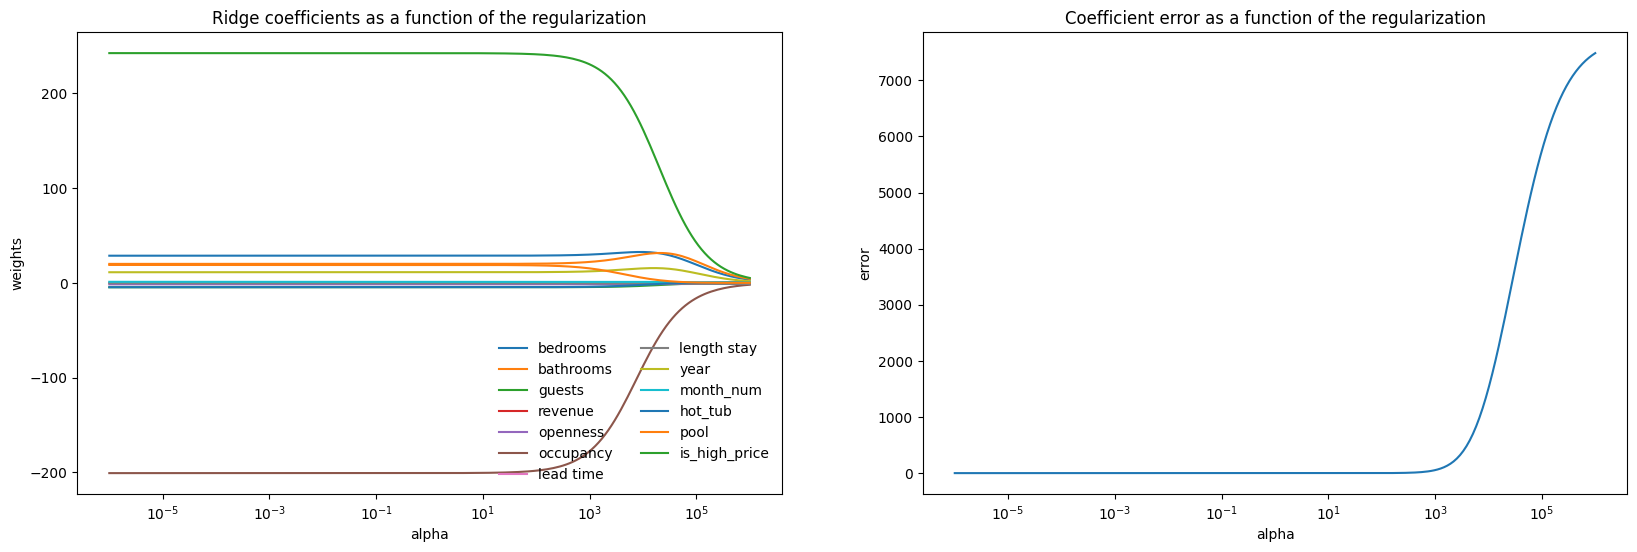

In [52]:
# Display results
plt.figure(figsize = (20, 6))

plt.subplot(121)
ax = plt.gca()
ax.plot(ridge_alphas, coefs)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.legend(X.columns, loc='lower right', ncol=2, frameon=False)
plt.title('Ridge coefficients as a function of the regularization')
plt.axis('tight')

plt.subplot(122)
ax = plt.gca()
ax.plot(ridge_alphas, errors)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('error')
plt.title('Coefficient error as a function of the regularization')
plt.axis('tight')

plt.show()

In [53]:
optimal_ridge = RidgeCV(alphas=ridge_alphas, cv=10)
optimal_ridge.fit(X, y)
print('Alpha:', optimal_ridge.alpha_)
print('Score:', optimal_ridge.score(X, y))

Alpha: 209.70464013232308
Score: 0.7365106838331817


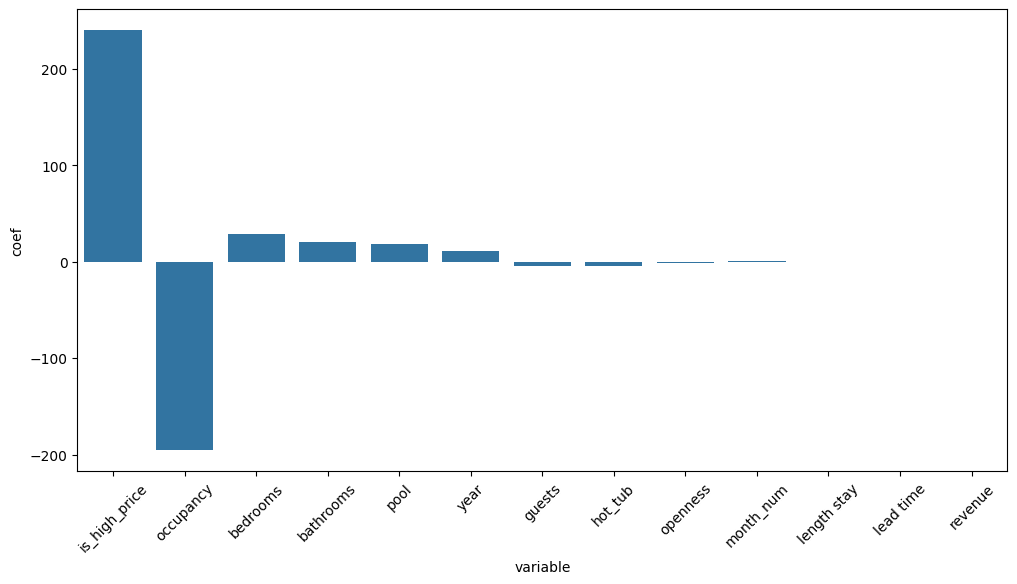

In [54]:
view_coeff(X, optimal_ridge)

In [55]:
optimal_ridge.coef_

array([ 2.89933823e+01,  2.05428529e+01, -4.56727819e+00,  3.42491641e-02,
       -1.53375541e+00, -1.95454796e+02,  8.22670105e-02, -3.24100472e-01,
        1.14729065e+01,  1.14932672e+00, -4.42645932e+00,  1.80652934e+01,
        2.39975499e+02])

### **Lasso**

In [56]:
## Calculate Lasso Regression model

# create a model object to hold the modelling parameters
lassomodel = Lasso()

# keep track of the intermediate results for coefficients and errors
coefs_lasso = []
errors_lasso = []

# create a range of alphas to calculate
lasso_alphas = np.logspace(-6, 6, 200) #lambda in the slides

# Train the model with different regularization strengths
for a in lasso_alphas:
    lassomodel.set_params(alpha = a)
    lassomodel.fit(X, y)
    coefs_lasso.append(lassomodel.coef_)
    errors_lasso.append(mean_squared_error(lassomodel.coef_, model.coef_))

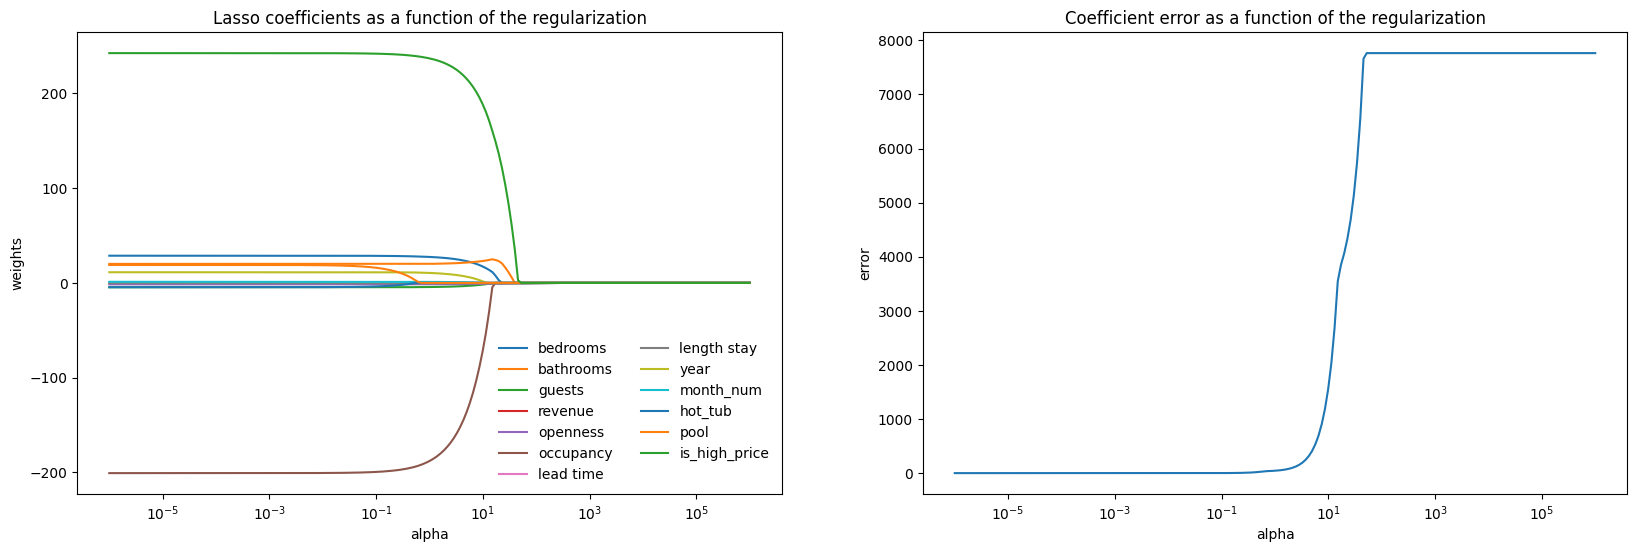

In [57]:
# Display results
plt.figure(figsize = (20, 6))

plt.subplot(121)
ax = plt.gca()
ax.plot(lasso_alphas, coefs_lasso)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.legend(X.columns, loc='lower right', ncol=2, frameon=False)
plt.title('Lasso coefficients as a function of the regularization')
plt.axis('tight')

plt.subplot(122)
ax = plt.gca()
ax.plot(lasso_alphas, errors_lasso)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('error')
plt.title('Coefficient error as a function of the regularization')
plt.axis('tight')

plt.show()

In [58]:
optimal_lasso = LassoCV(alphas=lasso_alphas, cv=10)
optimal_lasso.fit(X, y)
print('Alpha:', optimal_lasso.alpha_)
print('Score:', optimal_lasso.score(X, y))

Alpha: 0.7067181273927491
Score: 0.7363363333054296


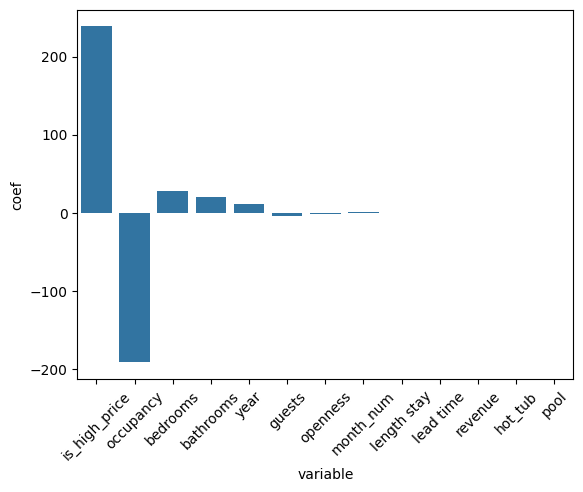

In [59]:
# Plot Coefficient
def view_coeff(X, model):
    model_coefs = pd.DataFrame({'variable': X.columns,
                                'coef': model.coef_,
                                'abs_coef': np.abs(model.coef_)})
    model_coefs.sort_values('abs_coef', inplace=True, ascending=False)
    sns.barplot(x="variable", y="coef", data=model_coefs)
    plt.xticks(rotation=45)
    plt.show()

view_coeff(X, optimal_lasso)

### **Model Comparison**

In [60]:
# Build the ridge and lasso using optimal alpha

# Get predictions from optimal models
y_pred_ridge = optimal_ridge.predict(X)
y_pred_lasso = optimal_lasso.predict(X)

# Need to fit the Lasso and Ridge outside of cross_val_score like we did with the ridge

In [61]:
# model residuals:
ridge_residuals = y - y_pred_ridge
lasso_residuals = y - y_pred_lasso

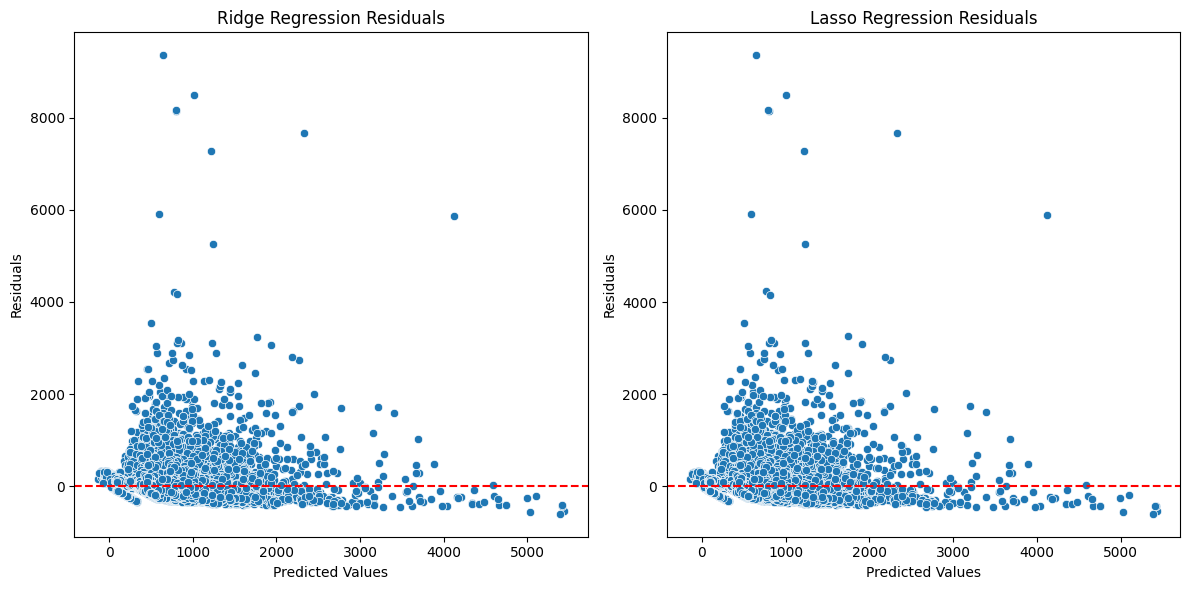

In [62]:
# Jointplot
import seaborn as sns # Ensure seaborn is imported for jointplot
import matplotlib.pyplot as plt # Ensure matplotlib.pyplot is imported

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_ridge, y=ridge_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Ridge Regression Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_lasso, y=lasso_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Lasso Regression Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

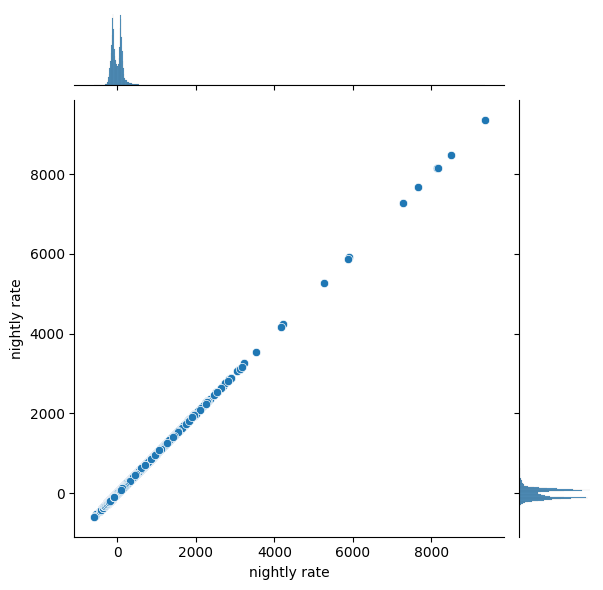

In [63]:
sns.jointplot(x=ridge_residuals, y=lasso_residuals);
plt.show()

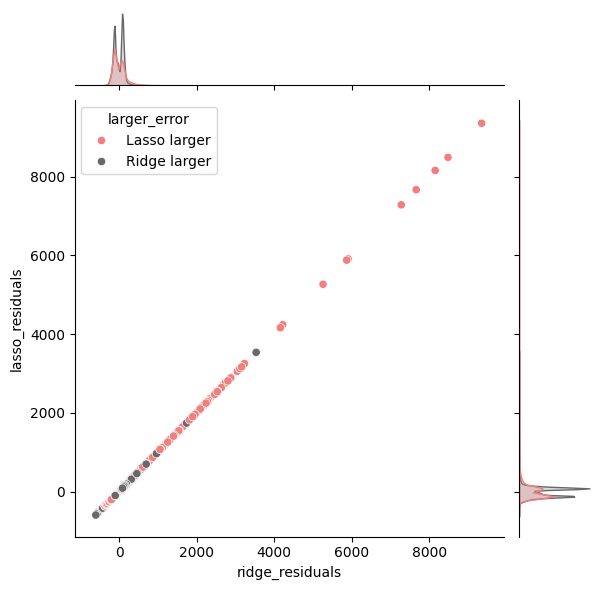

In [64]:
# 1. Create the temporary dataframe for the plot
df = pd.DataFrame({
    "ridge_residuals": ridge_residuals,
    "lasso_residuals": lasso_residuals
})

# 2. Create the grouping variable
df["larger_error"] = np.where(
    abs(df["ridge_residuals"]) > abs(df["lasso_residuals"]),
    "Ridge larger",
    "Lasso larger"
)

# 3. Generate the plot
sns.jointplot(
    data=df,
    x="ridge_residuals",
    y="lasso_residuals",
    hue="larger_error",
    palette={"Ridge larger": "dimgrey", "Lasso larger": "lightcoral"} # Using your theme colors!
)

plt.show()

## 3.Logistic Regression Model

#### **Home Size**

In [65]:
# 1. Define the features you want to use
features = ['bedrooms', 'bathrooms']

# 2. Set Target (y) and Features (X)
y = airbnb['is_high_price']
X = airbnb[features]  # Use square brackets [] to select the columns

In [66]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [67]:
# Create Model
model = LogisticRegression()

In [68]:
# Fit Model
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [69]:
# 1. Access the first (and only) row of the coefficients array
coefficients = model.coef_[0]

# 2. Pair them with the feature names
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': coefficients})

print(feature_importance)

     Feature  Importance
0   bedrooms    0.435665
1  bathrooms    0.551194


In [70]:
# Extract the intercept value
intercept = model.intercept_[0]

print(f"The computed intercept is: {intercept}")

The computed intercept is: -2.783390794071607


In [71]:
print(set(zip(features, model.coef_[0])))

{('bedrooms', np.float64(0.43566543429806787)), ('bathrooms', np.float64(0.5511937147582522))}


In [72]:
for col in zip(X_train.columns, model.coef_[0]):
    print('{:<10s}  {:+.06f}'.format(col[0], col[1]))  # Nb. increase 10 for longer names

bedrooms    +0.435665
bathrooms   +0.551194


In [73]:
# Calculate accuracy for the training set
train_accuracy = model.score(X_train, y_train)
print(f"Training Accuracy: {train_accuracy:.2%}")

Training Accuracy: 62.53%


In [74]:
# Calculate accuracy for the test set
test_accuracy = model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2%}")

Test Accuracy: 62.80%


#### **Amenities**

In [75]:
# Update your Feature matrix (X) to include these new columns
y = airbnb['is_high_price']
X = airbnb[['bedrooms', 'bathrooms', 'pool', 'hot_tub']]

In [76]:
# --- Train, Test, Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [77]:
# --- Create Model ---
model = LogisticRegression()

# --- Fit ---
model.fit(X_train, y_train)

# --- Score ---
train_accuracy = model.score(X_train, y_train)
print(f"Training Accuracy: {train_accuracy:.2%}")
test_accuracy = model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2%}")

Training Accuracy: 62.80%
Test Accuracy: 62.76%


Understanding the model errors: **The Confusion Matrix:**

In [78]:
# --- Confusion Matrix ---
y_pred_class = model.predict(X_test)
print(metrics.confusion_matrix(y_test, y_pred_class))

[[10726  3860]
 [ 6997  7571]]


**The ROC curve**

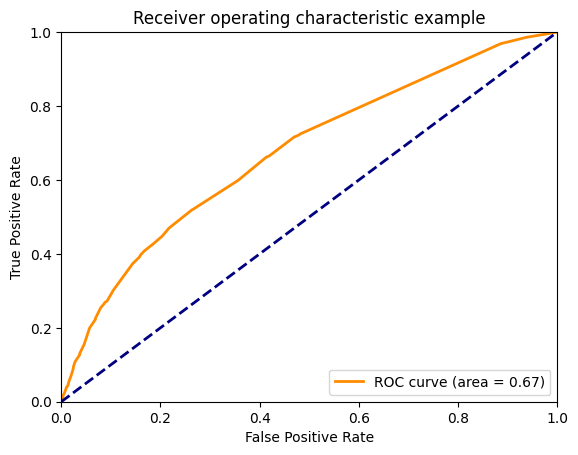

In [79]:
# Generate the prediction values for each of the test observations using predict_proba() function rather than just predict
preds = model.predict_proba(X_test)[:,1]

# Store the false positive rate(fpr), true positive rate (tpr) in vectors for use in the graph
fpr, tpr, _ = metrics.roc_curve(y_test, preds)

# Store the Area Under the Curve (AUC) so we can annotate our graph with this metric
roc_auc = metrics.auc(fpr, tpr)

# Plot the ROC Curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw = lw, label = 'ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color = 'navy', lw = lw, linestyle = '--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc = "lower right")
plt.show()

#### **City & Season** *(Categorical Predictors)*

In [80]:
# Select your numerical columns AND your new boolean/categorical columns
features = [
    'bedrooms', 'bathrooms', 'pool', 'hot_tub', 
    'city_Joshua Tree', 'city_Yucca Valley', 'city_Big Bear Lake',
    'season_Summer', 'season_Winter', 'season_Spring'
]
X = airbnb[features]
y = airbnb['is_high_price']

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [82]:
# Build Model
model = LogisticRegression()

# Fit Model
model.fit(X_train, y_train)

# Score
train_accuracy = model.score(X_train, y_train)
print(f"Training Accuracy: {train_accuracy:.2%}")
test_accuracy = model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2%}")

Training Accuracy: 67.25%
Test Accuracy: 67.82%


In [83]:
# 1. Get the predictions
y_pred_class = model.predict(X_test)

# 2. Generate the matrix
cm = metrics.confusion_matrix(y_test, y_pred_class)
print(cm)

# 3. Make it readable
print(f"True Negatives (Correct Low Price): {cm[0][0]}")
print(f"False Positives (Cheap, but predicted High): {cm[0][1]}")
print(f"False Negatives (Expensive, but predicted Low): {cm[1][0]}")
print(f"True Positives (Correct High Price): {cm[1][1]}")

[[10491  4095]
 [ 5288  9280]]
True Negatives (Correct Low Price): 10491
False Positives (Cheap, but predicted High): 4095
False Negatives (Expensive, but predicted Low): 5288
True Positives (Correct High Price): 9280


**Plot the ROC curve for the new model**

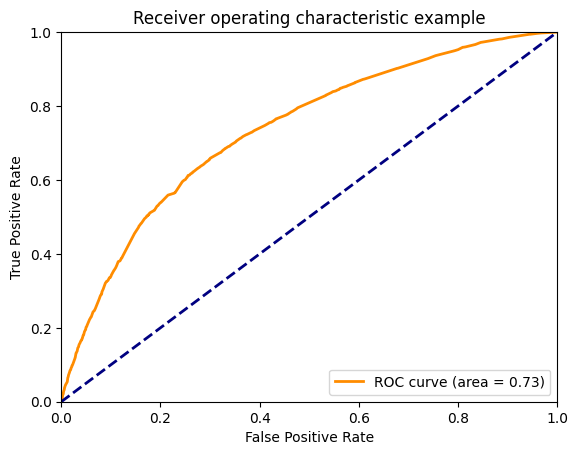

In [84]:
# ANSWER
# Generate the prediction values for each of the test observations using predict_proba() function rather than just predict
preds = model.predict_proba(X_test)[:,1]

# Store the false positive rate(fpr), true positive rate (tpr) in vectors for use in the graph
fpr, tpr, _ = metrics.roc_curve(y_test, preds)

# Store the Area Under the Curve (AUC) so we can annotate our graph with this metric
roc_auc = metrics.auc(fpr, tpr)

# Plot the ROC Curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw = lw, label = 'ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color = 'navy', lw = lw, linestyle = '--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc = "lower right")
plt.show()

In [85]:
# ANSWER
# Set Feature Both Numerical, Categorical
# Create a dataframe of the features and their coefficients
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

# Sort by the absolute value to see the strongest predictors
importance['Abs_Coefficient'] = importance['Coefficient'].abs()
print(importance.sort_values(by='Abs_Coefficient', ascending=False))

              Feature  Coefficient  Abs_Coefficient
8       season_Winter     1.005214         1.005214
1           bathrooms     0.531851         0.531851
0            bedrooms     0.472311         0.472311
2                pool     0.426630         0.426630
3             hot_tub     0.417731         0.417731
6  city_Big Bear Lake     0.342028         0.342028
7       season_Summer    -0.305432         0.305432
9       season_Spring    -0.239938         0.239938
5   city_Yucca Valley     0.127637         0.127637
4    city_Joshua Tree     0.014695         0.014695


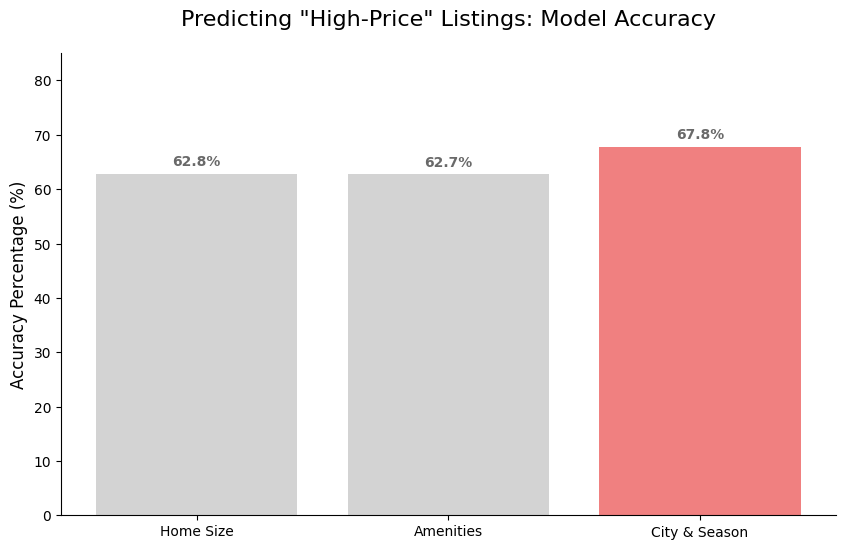

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ['Home Size', 'Amenities', 'City & Season']
accuracy = [62.8, 62.7, 67.8] # Data from your cells [85], [89], [95]

plt.figure(figsize=(10, 6))
colors = ['lightgrey', 'lightgrey', 'lightcoral'] # Highlighting the winner

bars = plt.bar(models, accuracy, color=colors)

# Add the % labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', 
             ha='center', va='bottom', fontweight='bold', color='dimgrey')

plt.title('Predicting "High-Price" Listings: Model Accuracy', fontsize=16, pad=20)
plt.ylabel('Accuracy Percentage (%)', fontsize=12)
plt.ylim(0, 85) # Leave room for labels
sns.despine()

plt.savefig('model_accuracy_comparison.png', transparent=True, dpi=300)
plt.show()

C:\Users\mia62\AppData\Local\Temp\ipykernel_14920\969835369.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=impact, y=top_features, palette=['lightcoral', 'dimgrey', 'dimgrey', 'dimgrey', 'dimgrey'])


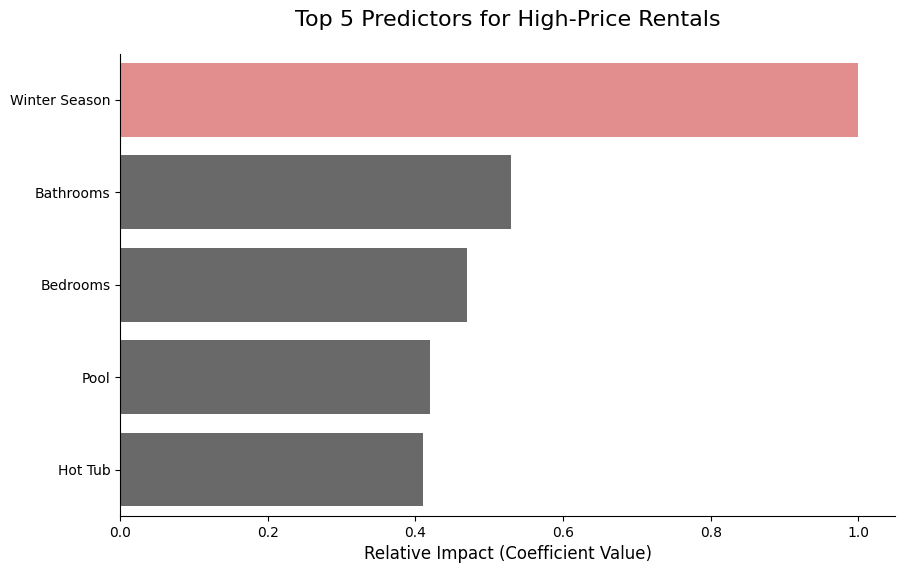

In [87]:
# Data from your Cell [98]
top_features = ['Winter Season', 'Bathrooms', 'Bedrooms', 'Pool', 'Hot Tub']
impact = [1.00, 0.53, 0.47, 0.42, 0.41]

plt.figure(figsize=(10, 6))
sns.barplot(x=impact, y=top_features, palette=['lightcoral', 'dimgrey', 'dimgrey', 'dimgrey', 'dimgrey'])

plt.title('Top 5 Predictors for High-Price Rentals', fontsize=16, pad=20)
plt.xlabel('Relative Impact (Coefficient Value)', fontsize=12)
plt.ylabel('') # Clean up Y axis
sns.despine()

plt.savefig('feature_importance.png', transparent=True, dpi=300)
plt.show()

## Visualizations

**Graph Fonts**

In [88]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Century Gothic Pro', 'Century Gothic', 'Arial']


**Graph Color Palettes**

In [89]:
city_colors = {
    'Joshua Tree':'#FF8C27', 
    'Yucca Valley':'#D93334', 
    'Big Bear City':'#4EAF4E', 
    'Big Bear Lake':'#297DB8',
    'Panorama Heights' :'#FFE66D'
}

**Visuals by Home Size (Bed/Bath)**

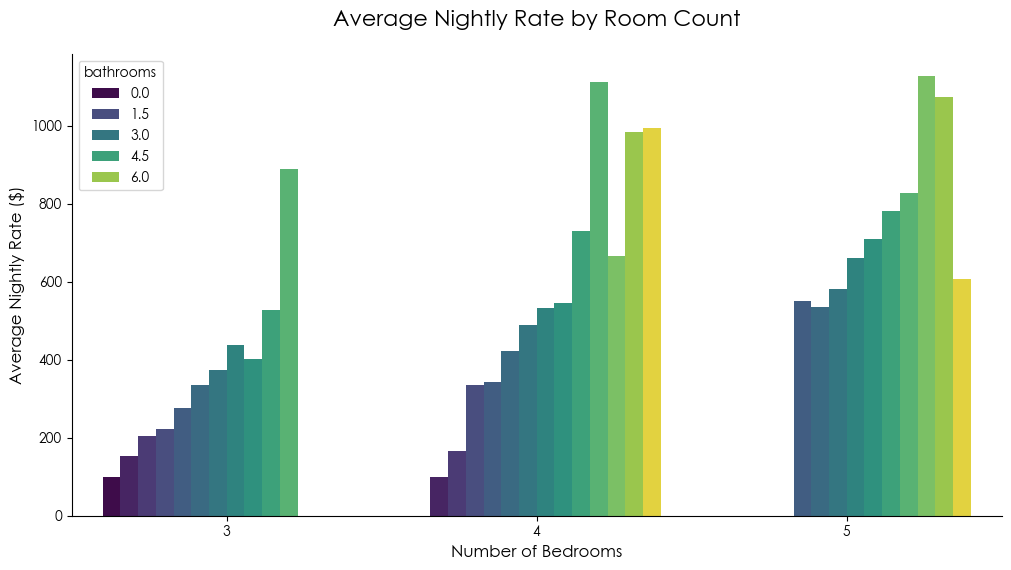

In [90]:
# 1. Create the figure
plt.figure(figsize=(12, 6))

# 2. Plot Average Nightly Rate by Bedrooms, segmented by Bathrooms
# We use 'hue' for bathrooms to show the comparison side-by-side
ax = sns.barplot(
    data=airbnb, 
    x='bedrooms', 
    y='nightly rate', 
    hue='bathrooms',
    palette='viridis', # Using a gradient since bathrooms are numerical
    errorbar=None      # Removes the lines to keep the brand look clean
)

# 3. Apply your styling
plt.title('Average Nightly Rate by Room Count', fontsize=16, pad=20)
plt.xlabel('Number of Bedrooms', fontsize=12)
plt.ylabel('Average Nightly Rate ($)', fontsize=12)
sns.despine() # Removes the top and right borders for a modern look

plt.savefig('size.png', transparent=True, dpi=300)

plt.show()

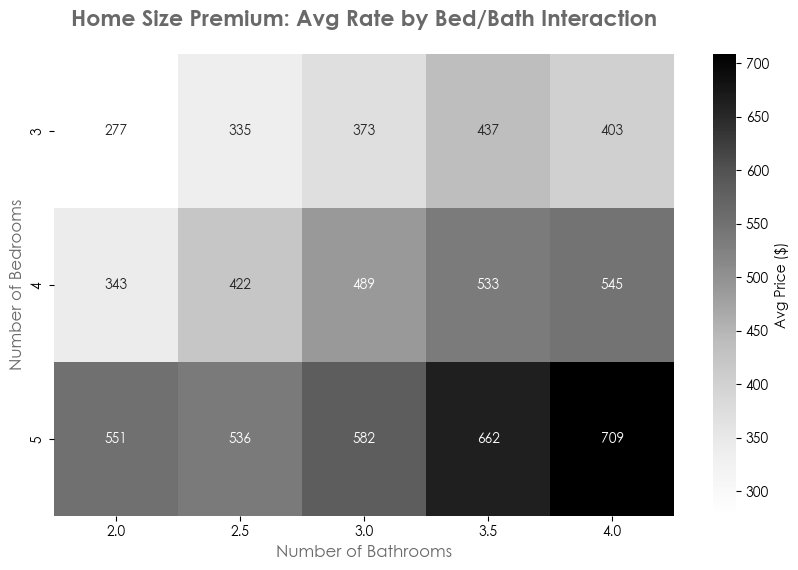

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group the data and pivot for the heatmap
# Filter for typical counts (3-5 beds, 2-4 baths) to keep it clean
size_price_pivot = airbnb.groupby(['bedrooms', 'bathrooms'])['nightly rate'].mean().unstack().loc[3:5, 2:4]

plt.figure(figsize=(10, 6))

# 2. Use a 'Greys' cmap to match your requested dimgrey theme
ax = sns.heatmap(size_price_pivot, annot=True, fmt=".0f", cmap='Greys', cbar_kws={'label': 'Avg Price ($)'})

# 3. Apply your styling
plt.title('Home Size Premium: Avg Rate by Bed/Bath Interaction', fontsize=16, pad=20, fontweight='bold', color='dimgrey')
plt.ylabel('Number of Bedrooms', fontsize=12, color='dimgrey')
plt.xlabel('Number of Bathrooms', fontsize=12, color='dimgrey')

# Save for Adobe Express
plt.savefig('size_bed_bath_heatmap.png', transparent=True, dpi=300)
plt.show()

**Visuals by Amenities (Pool/Hot Tub)**

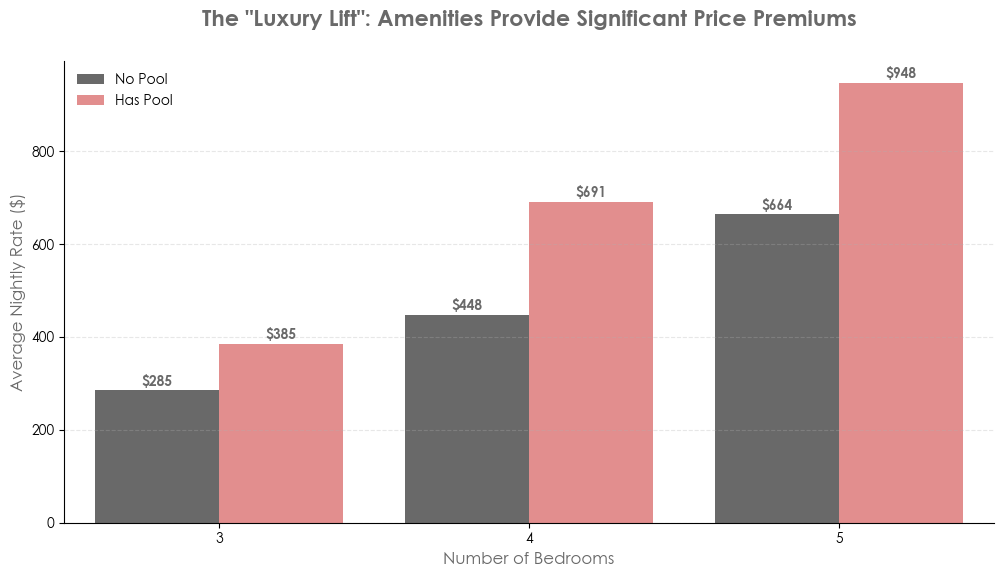

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data (Averages by Bedroom Count and Pool status)
df_plot = airbnb.groupby(['bedrooms', 'pool'])['nightly rate'].mean().reset_index()

# Map Pool status to text for a cleaner legend
df_plot['Pool?'] = df_plot['pool'].map({0.0: 'No Pool', 1.0: 'Has Pool'})

plt.figure(figsize=(12, 6))

# 2. Create the Bar Plot (using requested 'coral' palette for contrast)
# We set dodge=True so the bars sit side-by-side for comparison
sns.barplot(data=df_plot, x='bedrooms', y='nightly rate', hue='Pool?', palette=['dimgrey', 'lightcoral'], errorbar=None)

# 3. Add exact value labels on top of the bars
for i in range(len(df_plot)):
    row = df_plot.iloc[i]
    # Adjust x-position slightly for dodge=True grouping
    x_pos = (row['bedrooms'] - 3) # adjust base
    x_pos += -0.2 if row['Pool?'] == 'No Pool' else 0.2
    
    plt.text(x_pos, row['nightly rate'] + 10, f"${row['nightly rate']:.0f}", 
             ha='center', fontweight='bold', color='dimgrey', fontsize=10)

# 4. Final Formatting
plt.title('The "Luxury Lift": Amenities Provide Significant Price Premiums', fontsize=16, pad=25, fontweight='bold', color='dimgrey')
plt.ylabel('Average Nightly Rate ($)', fontsize=12, color='dimgrey')
plt.xlabel('Number of Bedrooms', fontsize=12, color='dimgrey')
plt.legend(title='', frameon=False, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

# Save for your presentation
plt.savefig('amenities_luxury_lift.png', transparent=True, dpi=300)
plt.show()

**Visuals by City & Season (Big Bear, Yucca, Joshua Tree//Winter, Spring, Summer)**

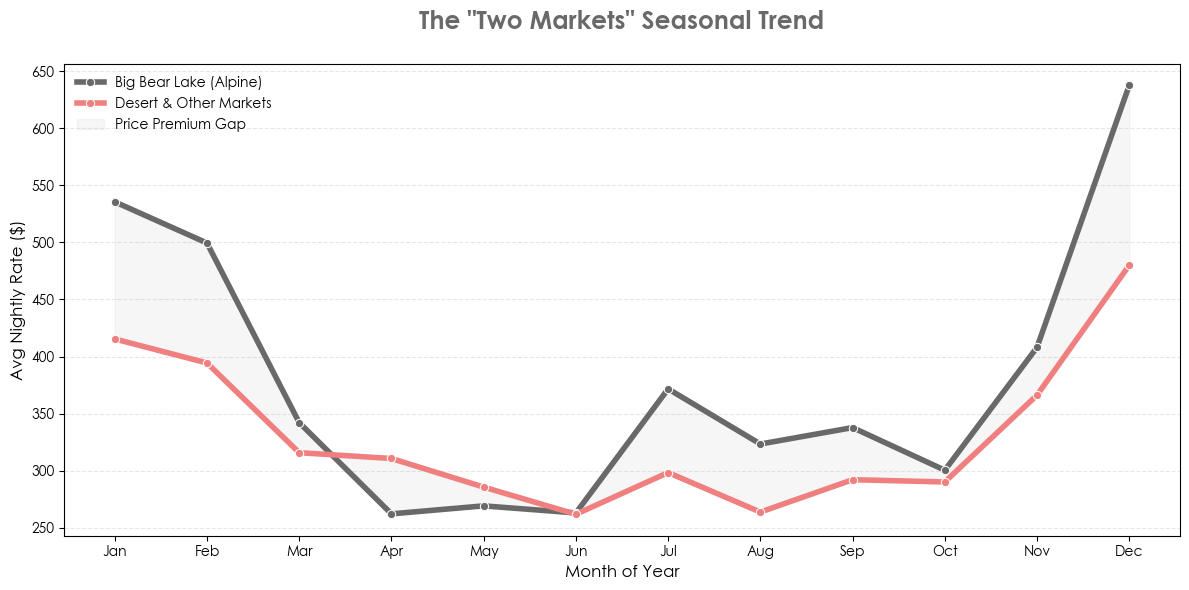

In [93]:
# 1. Grouping data for the plot
# This separates Big Bear Lake from the "Desert/Other" markets
seasonal_data = airbnb.groupby(['month_num', 'city_Big Bear Lake'])['nightly rate'].mean().unstack()

# 2. Set the figure and styling
plt.figure(figsize=(12, 6))
sns.despine() # Removes borders

# --- THE COLOR AND LEGEND CHANGE ---
# Alpine is now 'dimgrey' to highlight its distinct winter peak, 
# while other cities stay lightcoral for the desert trend.
sns.lineplot(x=seasonal_data.index, y=seasonal_data[True], 
             color='dimgrey', # CHANGED from '#297DB8' (blue)
             lw=4, label='Big Bear Lake (Alpine)', marker='o')

sns.lineplot(x=seasonal_data.index, y=seasonal_data[False], 
             color='lightcoral', # Kept from original request
             lw=4, label='Desert & Other Markets', marker='o')

# 3. Add a soft fill to highlight the gap during peak seasons
plt.fill_between(seasonal_data.index, seasonal_data[True], seasonal_data[False], 
                 color='lightgrey', alpha=0.2, label='Price Premium Gap')

# 4. Axis Labels: Change numbers 1-12 to names Jan-Dec
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# 5. Formatting for the slide
plt.title('The "Two Markets" Seasonal Trend', fontsize=18, pad=25, fontweight='bold', color='dimgrey')
plt.ylabel('Avg Nightly Rate ($)', fontsize=12)
plt.xlabel('Month of Year', fontsize=12)
plt.legend(frameon=False, loc='upper left', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('seasonal_trends_final.png', transparent=True, dpi=300)
plt.show()

C:\Users\mia62\AppData\Local\Temp\ipykernel_14920\4244739118.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=airbnb, x='City', y='nightly rate',


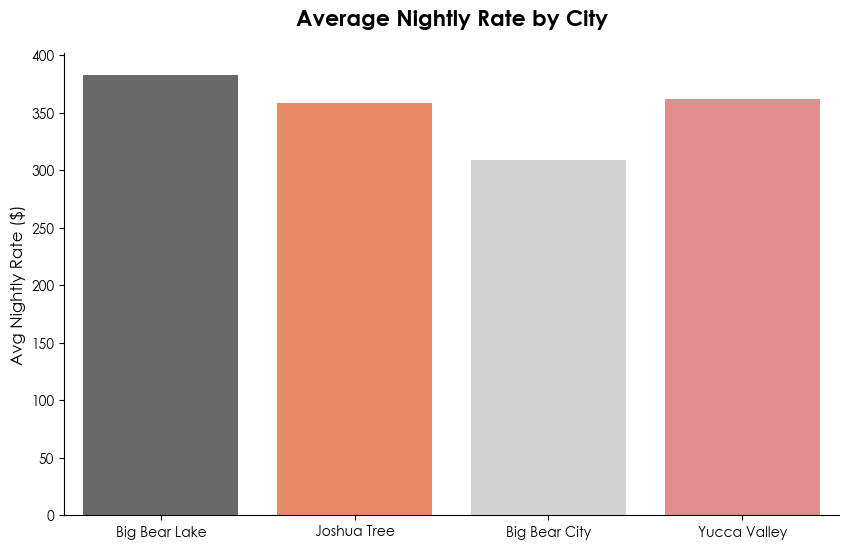

In [94]:
# 1. Reconstruct the City column for plotting
# Since Big Bear City was your 'drop_first' city, it's the default (where all others are 0)
def get_city_name(row):
    if row['city_Big Bear Lake']: return 'Big Bear Lake'
    if row['city_Joshua Tree']: return 'Joshua Tree'
    if row['city_Yucca Valley']: return 'Yucca Valley'
    return 'Big Bear City'

# Create a temporary column for plotting
airbnb['City'] = airbnb.apply(get_city_name, axis=1)

# 2. Plotting (Using your requested Palette)
plt.figure(figsize=(10, 6))
city_palette = {'Big Bear Lake': 'dimgrey', 'Big Bear City': 'lightgrey', 
                'Joshua Tree': 'coral', 'Yucca Valley': 'lightcoral'}

sns.barplot(data=airbnb, x='City', y='nightly rate', 
            palette=city_palette, errorbar=None)

plt.title('Average Nightly Rate by City', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Avg Nightly Rate ($)', fontsize=12)
plt.xlabel('')
sns.despine()

plt.savefig('city_impact_final.png', transparent=True, dpi=300)
plt.show()

In [95]:
airbnb.columns

Index(['unified_id', 'zipcode', 'bedrooms', 'bathrooms', 'guests', 'revenue',
       'openness', 'occupancy', 'nightly rate', 'lead time', 'length stay',
       'year', 'month_num', 'hot_tub', 'pool', 'city_Big Bear Lake',
       'city_Joshua Tree', 'city_Yucca Valley', 'host_type_Professionals',
       'host_type_Single Owners', 'season_Spring', 'season_Summer',
       'season_Winter', 'is_high_price', 'City'],
      dtype='object')

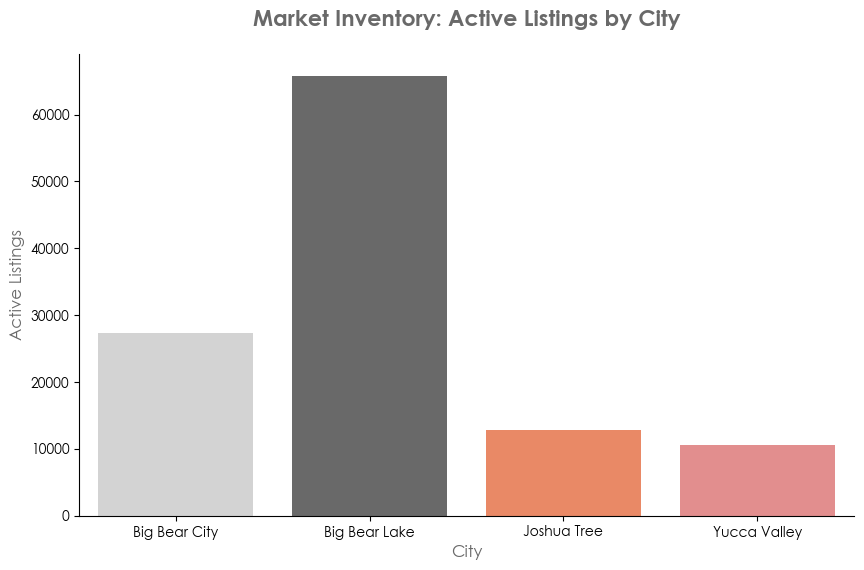

In [96]:
# 1. Set the figure size for a slide-friendly Layout
plt.figure(figsize=(10, 6))

# 2. Get the sorted list of cities for the x-axis
sorted_cities = sorted(market['city'].unique())

# 3. Define the custom palette based on your theme:
# Big Bear Lake: dimgrey, Big Bear City: lightgrey, 
# Joshua Tree: coral, Yucca Valley: lightcoral
custom_city_palette = {
    'Big Bear Lake': 'dimgrey',
    'Big Bear City': 'lightgrey',
    'Joshua Tree': 'coral',
    'Yucca Valley': 'lightcoral'
}

# 4. Generate the countplot
sns.countplot(
    data=market,
    x='city',
    order=sorted_cities,
    palette=custom_city_palette,
    hue='city',
    legend=False
)

# 5. Add professional styling
plt.title('Market Inventory: Active Listings by City', fontsize=16, pad=20, fontweight='bold', color='dimgrey')
plt.xlabel('City', fontsize=12, color='dimgrey')
plt.ylabel('Active Listings', fontsize=12, color='dimgrey')

# 6. Clean up the Look
sns.despine()

# Save for your Adobe Express presentation
plt.savefig('totalcity_sorted_themed.png', transparent=True, dpi=300)
plt.show()

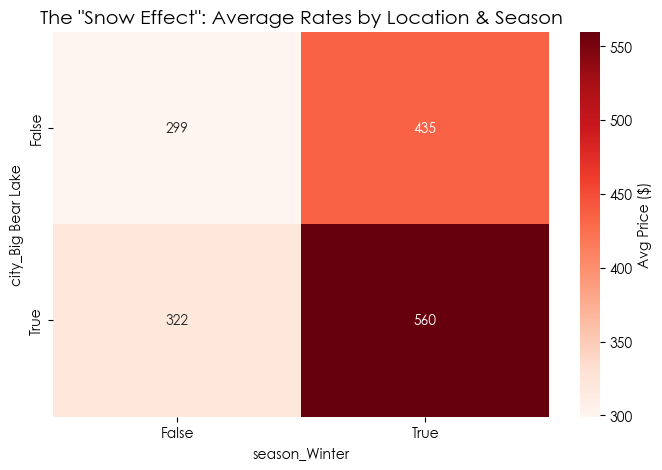

In [97]:
# Create a pivot table to see Average Nightly Rate by City and Season
# Note: You'll need to re-map 'season' if it's currently dummies
city_season_price = airbnb.groupby(['city_Big Bear Lake', 'season_Winter'])['nightly rate'].mean().unstack()

plt.figure(figsize=(8, 5))
sns.heatmap(city_season_price, annot=True, fmt=".0f", cmap='Reds', cbar_kws={'label': 'Avg Price ($)'})
plt.title('The "Snow Effect": Average Rates by Location & Season', fontsize=14)
plt.show()

In [98]:
# Exporting the cleaned dataset for Tableau
airbnb.to_csv('cleaned_airbnb_data.csv', index=False)